# Exercise 1

In [1]:
import numpy as np

In [2]:
beta = 0.9
W = 5
T = 4

def solve_backwards(beta,W,T):
    Vstar_bi = np.nan + np.zeros([W+1,T]) #Make a (W+1)xT matrix of NaNs
    Cstar_bi = np.nan + np.zeros([W+1,T]) #Make a (W+1)xT matrix of NaNs
    Cstar_bi[:,T-1] = np.arange(W+1) 
    Vstar_bi[:,T-1] = np.sqrt(Cstar_bi[:,T-1])

    for t in range(T-2, -1, -1):
        for w in range(W+1):
            c = np.arange(w+1)
            w_c = w - c
            V_next = Vstar_bi[w_c,t+1]
            V_guess = np.sqrt(c) + beta * V_next
            Vstar_bi[w,t] = np.amax(V_guess)
            Cstar_bi[w,t] = np.argmax(V_guess)
    return Cstar_bi, Vstar_bi

C10,V10 = solve_backwards(beta=beta,W=W,T=T)

W_now = W

def simulate(Cstar,T,W):
    C_backwards = np.empty(T)
    W_now = W
    for t in range(T):
        W_now = int(W_now)
        C_backwards[t] = Cstar[W_now,t]
        W_now = W_now - C_backwards[t]
    return C_backwards

C_sim = simulate(Cstar=C10,T=T,W=W)

print('Solution for C with T =',T,'and W =', W , ': C =',C_sim)

Solution for C with T = 4 and W = 5 : C = [2. 1. 1. 1.]


In [3]:
Vstar_bi = np.nan+np.zeros([W+1,T]) #Make a (W+1)xT matrix of NaNs
Cstar_bi = np.nan + np.zeros([W+1,T]) #Make a (W+1)xT matrix of NaNs
Cstar_bi[:,T-1] = np.arange(W+1) #Set the last period to be the whole cake
Vstar_bi[:,T-1] = np.sqrt(Cstar_bi[:,T-1]) #Compute the value of the last period

    
for t in range(T-2, -1, -1):  #from period T-2, until period 0, backwards  
    
    #loop over states
    for w in range(W+1):
        c = np.arange(w+1)
        w_c = w - c #w_c is the remaining cake after consumption
        V_next = Vstar_bi[w-c,t+1]

        V_guess = np.sqrt(c)+beta*V_next #(w+1) vector of possible values next period
        Vstar_bi[w,t] = np.amax(V_guess) #Find the maximum value
        Cstar_bi[w,t] = np.argmax(V_guess) #Find the corresponding consumption (in this case equal to the index of the maximum value)
        
C_backwards = np.empty(T) #Make an empty vector of length T to store optimal consumption in
W_now = W #Set the initial cake size to W

for t in range(T): #Loop forwards over periods
    W_now = int(W_now)   # change the type to integreger 0,1,2,3 and so on
    C_backwards[t] = Cstar_bi[W_now,t]
    W_now = W_now-C_backwards[t]# Hint, use the policy function, C, you found above to calculate optimal consumption and then update W_now
    
print(Cstar_bi)

[[0. 0. 0. 0.]
 [1. 1. 1. 1.]
 [1. 1. 1. 2.]
 [1. 1. 2. 3.]
 [1. 2. 2. 4.]
 [2. 2. 3. 5.]]


In [4]:
Vstar_bi = np.nan+np.zeros([W+1,T]) #Make a (W+1)xT matrix of NaNs
Cstar_bi = np.nan + np.zeros([W+1,T]) #Make a (W+1)xT matrix of NaNs
Cstar_bi[:,T-1] = np.arange(W+1) #Set the last period to be the whole cake
Vstar_bi[:,T-1] = np.sqrt(Cstar_bi[:,T-1]) #Compute the value of the last period
t = 2
for w in range(W+1):
    c = np.arange(w+1)
    w_c = w - c #w_c is the remaining cake after consumption
    V_next = Vstar_bi[w-c,t+1]

    V_guess = np.sqrt(c)+beta*V_next #(w+1) vector of possible values next period
    Vstar_bi[w,t] = np.amax(V_guess) #Find the maximum value
    Cstar_bi[w,t] = np.argmax(V_guess) #Find the corresponding consumption (in this case equal to the index of the maximum value)
print(Cstar_bi)


[[nan nan  0.  0.]
 [nan nan  1.  1.]
 [nan nan  1.  2.]
 [nan nan  2.  3.]
 [nan nan  2.  4.]
 [nan nan  3.  5.]]


# Exercise 2

In [5]:
# Setup
beta = 0.90
W = 5
grid_W = np.arange(W+1)
Cstar = np.zeros([W+1])

# Parameters for VFI
max_iter = 200   # maximum number of iterations
delta = 1000 #difference between V_next and V_now
tol = 10e-2 #convergence tol. level
it = 0  #iteration counter 
V_now = np.zeros([W+1]) #arbitrary starting values

while (max_iter>= it and tol<delta):
    it = it+1
    V_next = V_now.copy()
    for w in range(W+1):
        c = np.arange(w+1)
        w_c = w - c
        V_guess = np.sqrt(c)+beta*V_next[w_c]
        V_now[w] = np.amax(V_guess)
        Cstar[w] = np.argmax(V_guess)
    delta = np.amax(np.abs(V_now - V_next))
print(Cstar)

[0. 1. 1. 1. 1. 1.]


In [6]:
def solve_VFI(beta,W,max_iter,tol,delta):
    Cstar = np.zeros([W+1])
    it = 0
    V_now = np.zeros([W+1])

    while (max_iter>= it and tol<delta):
        it = it+1
        V_next = V_now.copy()
        for w in range(W+1):
            c = np.arange(w+1)
            w_c = w - c
            V_guess = np.sqrt(c)+beta*V_next[w_c]
            V_now[w] = np.amax(V_guess)
            Cstar[w] = np.argmax(V_guess)
        delta = np.amax(np.abs(V_now - V_next))
    return Cstar

solve_VFI(beta=beta,W=W,max_iter=max_iter,tol=tol,delta=1000)

array([0., 1., 1., 1., 1., 1.])

# Exercise 3

In [7]:
def solve_consumption_grid_search(num_W,num_C,W,max_iter,tol,beta):
    C = np.zeros(num_W)
    V = np.zeros(num_W)

    grid_C = np.linspace(0.0,1.0,num_C)
    grid_W = np.linspace(0.0,W,num_W)

    delta = 1000
    it = 0

    while (max_iter>= it and tol<delta):
        it += 1
        V_next = V.copy()
        for iw,w in enumerate(grid_W):
            c = grid_C*w
            w_c = w - c
            V_guess = np.sqrt(c) + beta*np.interp(w_c,grid_W,V_next)
            index = np.argmax(V_guess)
            C[iw] = c[index]
            V[iw] = np.amax(V_guess)

    delta = np.amax(np.abs(V-V_next))

    return V,C

beta, W, num_W, num_C, max_iter, tol = 0.9, 10, 200, 50, 200, 10e-5
solution_V, solution_C = solve_consumption_grid_search(num_W,num_C,W,max_iter,tol,beta)

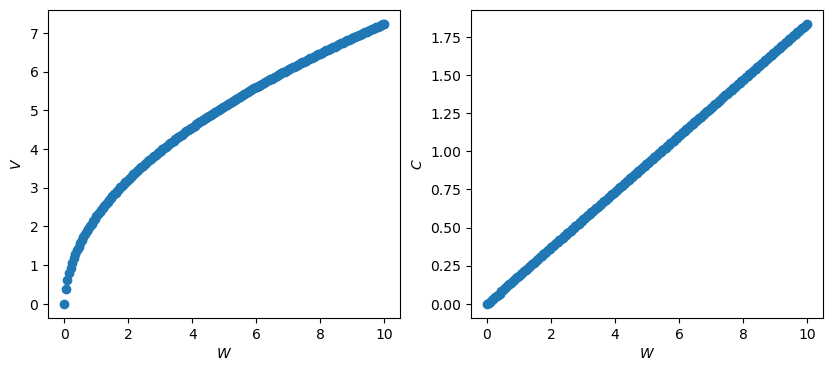

In [8]:
import matplotlib.pyplot as plt
def plot_solution(solution_V,solution_C):
    fig = plt.figure(figsize=(10,4)) # figsize is in inches...
    
    grid_W = np.linspace(0.0,W,num_W)

    ax = fig.add_subplot(1,2,1)
    ax.scatter(grid_W,solution_V)
    ax.set_xlabel("$W$")
    ax.set_ylabel("$V$")

    ax_right = fig.add_subplot(1,2,2)
    ax_right.scatter(grid_W,solution_C)
    ax_right.set_xlabel("$W$")
    ax_right.set_ylabel("$C$")
    plt.show()
    
plot_solution(solution_V,solution_C)

# Numerical integration

In [9]:
def u(c,eta):
    if eta == 1:
        return np.log(c)
    else:
        return (c**(1-eta)-1)/(1-eta)

In [10]:
n = 100000; eta = 1; mu = 2; sigma = 1;
x = np.random.lognormal(mu, sigma, n)
fx = u(x,eta)

Qn = np.mean(fx)
std_dev_Qn = np.std(fx)
se_Qn = std_dev_Qn/np.sqrt(n)

print(Qn)
print(std_dev_Qn)
print(se_Qn)

2.003534708779354
0.9970879210328223
0.003153068857905827


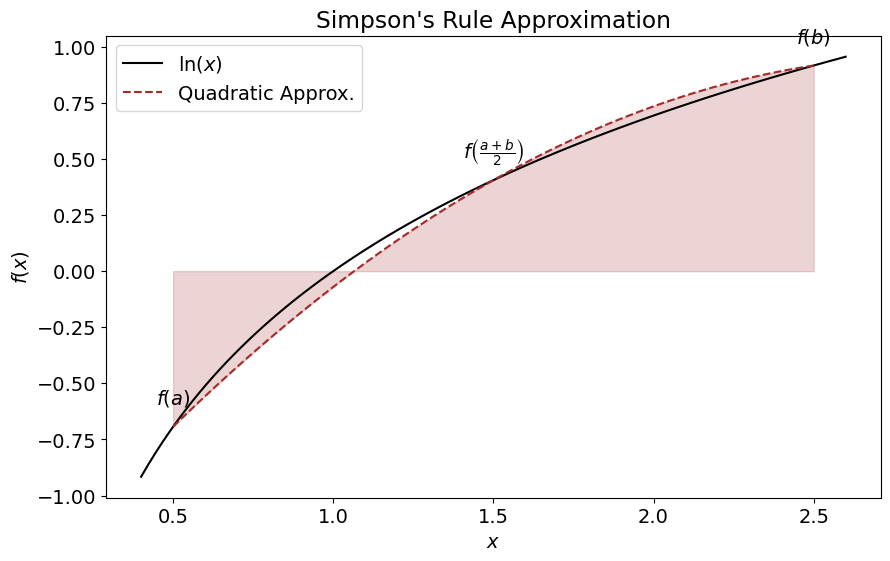

In [11]:
def f(x):
    fx = np.log(x)
    return fx

a, b = 0.5, 2.5
mid = (a+b)/2

x = np.linspace(a - 0.1, b + 0.1, 100)
quad_x = np.linspace(a, b, 100)

fa, fb, fmid = f(a), f(b), f(mid)

quad_y = fa * (quad_x - mid) * (quad_x - b) / ((a - mid) * (a - b)) + \
         fmid * (quad_x - a) * (quad_x - b) / ((mid - a) * (mid - b)) + \
         fb * (quad_x - a) * (quad_x - mid) / ((b - a) * (b - mid))

import matplotlib.pyplot as plt
# Plot
plt.rcParams.update({'font.size': 14})  # Adjust this for overall font size
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, f(x), 'k', label=r'$\ln(x)$')
ax.plot(quad_x, quad_y, 'brown', linestyle='dashed', label=r'Quadratic Approx.')
ax.fill_between(quad_x, quad_y, color='brown', alpha=0.2)
for x_val, f_val, label in zip([a, mid, b], [fa, fmid, fb], [r'$f(a)$', r'$f\left(\frac{a+b}{2}\right)$', r'$f(b)$']):
    ax.text(x_val, f_val + 0.1, label, ha='center')
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$f(x)$')
ax.legend(); ax.set_title("Simpson's Rule Approximation")
plt.show()